In [ ]:
# =====================================================================
# MACHINE LEARNING MIDTERM EXAM - EXPLORATORY DATA ANALYSIS
# STUDENT: CUONG DANG (W217887095)
# DATASET: TELCO CUSTOMER CHURN (7,043 ROWS)
# =====================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# ---------------------------------------------------------------------
# REQUIREMENT 1 & 3: DYNAMIC KAGGLE DOWNLOAD & PROGRAMMATIC 70/30 SPLIT
# ---------------------------------------------------------------------
print("--- FETCHING REMOTE DATASET FROM KAGGLE ---")
# Automatically downloads the latest version to a local cache directory
raw_path = kagglehub.dataset_download("blastchar/telco-customer-churn")
file_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
full_file_path = os.path.join(raw_path, file_name)

# Load the raw dataset into memory programmatically without manual edits
df = pd.read_csv(full_file_path)

#df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Programmatic split: 70% training data, 30% testing data
train_raw, test_data = train_test_split(df, test_size=0.30, random_state=42)

# Export the untouched testing data immediately to preserve validation matrix
test_data.to_csv('untouched_test_data.csv', index=False)

# Isolate a training copy to execute EDA and prevent data leakage
train_df = train_raw.copy()
print("--- INITIAL DATA MATRIX SHAPE ---")
print(f"Total Raw Rows: {df.shape}")
print(f"Training Split (70%): {train_df.shape}")
print(f"Testing Split (30% - Untouched): {test_data.shape}\n")

--- FETCHING REMOTE DATASET FROM KAGGLE ---
Using Colab cache for faster access to the 'telco-customer-churn' dataset.
--- INITIAL DATA MATRIX SHAPE ---
Total Raw Rows: (7043, 21)
Training Split (70%): (4930, 21)
Testing Split (30% - Untouched): (2113, 21)



/tmp/ipykernel_450/631185322.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=train_df, palette='Set2')


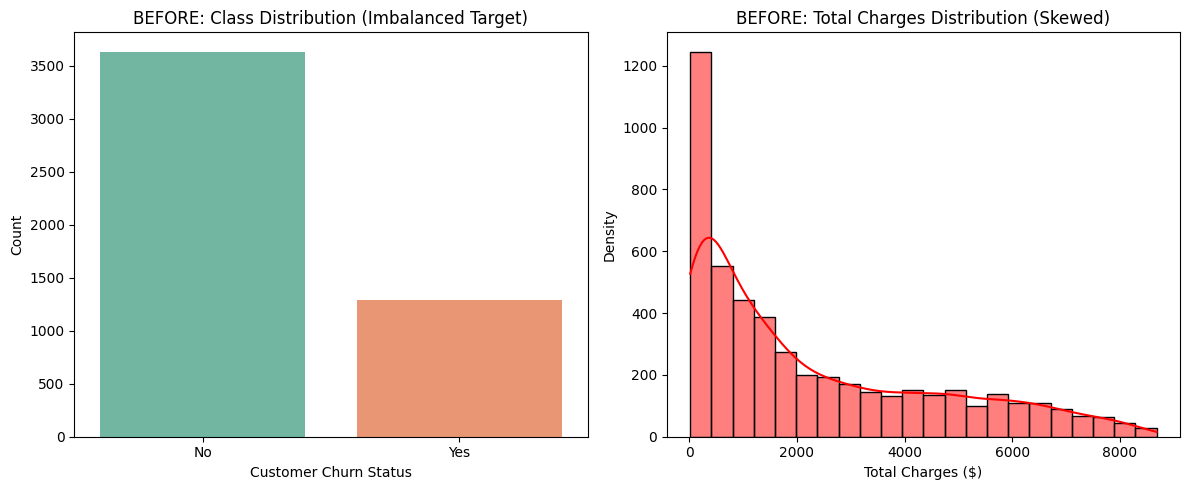

In [ ]:
# ---------------------------------------------------------------------
# REQUIREMENT 5: VISUALIZE ORIGINAL DISTRIBUTIONS (BEFORE)
# ---------------------------------------------------------------------
# Coerce total charges to numeric values for initial visual evaluation
train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')

plt.figure(figsize=(12, 5))

# Subplot 1: Target Variable Class Imbalance Profiling
plt.subplot(1, 2, 1)
sns.countplot(x='Churn', data=train_df, palette='Set2')
plt.title('BEFORE: Class Distribution (Imbalanced Target)')
plt.xlabel('Customer Churn Status')
plt.ylabel('Count')

# Subplot 2: Numerical Variable Density Distribution (Skewed)
plt.subplot(1, 2, 2)
sns.histplot(train_df['TotalCharges'].dropna(), kde=True, color='red')
plt.title('BEFORE: Total Charges Distribution (Skewed)')
plt.xlabel('Total Charges ($)')
plt.ylabel('Density')

plt.tight_layout()
plt.savefig('before_preprocessing_plots.png')
plt.show()


In [ ]:
# ---------------------------------------------------------------------
# REQUIREMENT 3 & 4: PROGRAMMATIC PREPROCESSING PIPELINE
# ---------------------------------------------------------------------
print("--- STARTING PROGRAMMATIC DATA PREPROCESSING VIA PYTHON ---")

# A. Missing Value Imputation (Filling NaNs with the Training Median)
initial_nulls = train_df['TotalCharges'].isnull().sum()
print(f"Initial missing cells in 'TotalCharges': {initial_nulls}")
total_charges_median = train_df['TotalCharges'].median()
train_df['TotalCharges'].fillna(total_charges_median, inplace=True)
print(f"Post-imputation missing cells: {train_df['TotalCharges'].isnull().sum()}\n")

# B. Categorical Feature Transformation (One-Hot Encoding)
categorical_features = ['gender', 'Partner', 'Dependents', 'Contract', 'PaymentMethod']
train_df = pd.get_dummies(train_df, columns=categorical_features, drop_first=True)
print("Successfully generated One-Hot Encoded matrices for categorical text blocks.\n")

# C. Class Balancing Framework (Minority Class Over-sampling)
df_majority = train_df[train_df.Churn == 'No']
df_minority = train_df[train_df.Churn == 'Yes']

df_minority_upsampled = resample(df_minority,
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=42)

train_df_balanced = pd.concat([df_majority, df_minority_upsampled])
print(f"Balanced Class Value Arrays: \n{train_df_balanced['Churn'].value_counts()}\n")

# D. Feature Scaling & Normalization (StandardScaler Implementation)
scaler = StandardScaler()
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
train_df_balanced[numerical_features] = scaler.fit_transform(train_df_balanced[numerical_features])
print("Successfully executed feature scaling over metric attributes.\n")

--- STARTING PROGRAMMATIC DATA PREPROCESSING VIA PYTHON ---
Initial missing cells in 'TotalCharges': 8
Post-imputation missing cells: 0

Successfully generated One-Hot Encoded matrices for categorical text blocks.

Balanced Class Value Arrays: 
Churn
No     3635
Yes    3635
Name: count, dtype: int64

Successfully executed feature scaling over metric attributes.



/tmp/ipykernel_450/2655901060.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['TotalCharges'].fillna(total_charges_median, inplace=True)


/tmp/ipykernel_450/3926480535.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=train_df_balanced, palette='Set1')


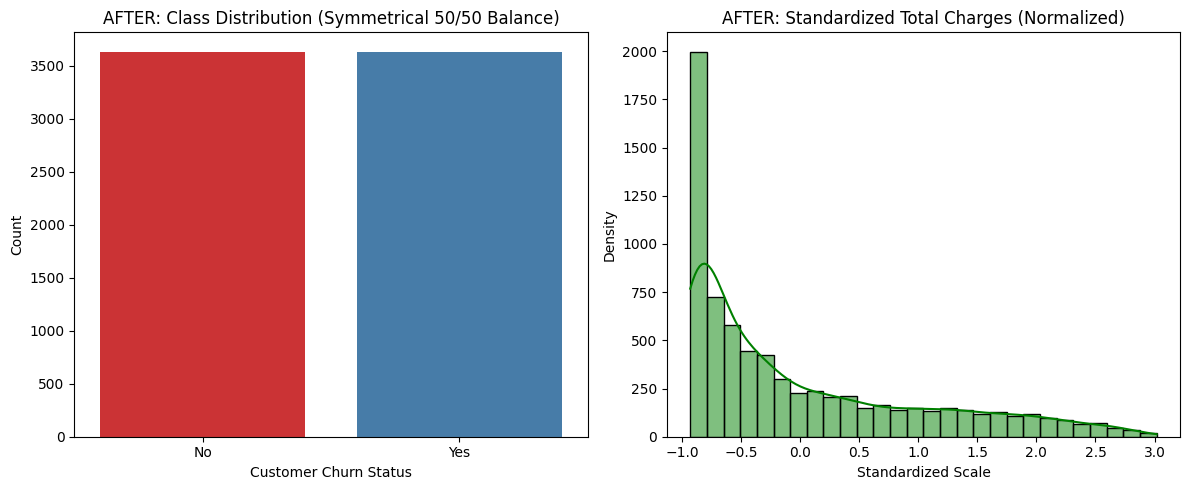

--- PREPROCESSED TRAINING SAMPLE PREVIEW ---
        tenure  MonthlyCharges  TotalCharges
1695  1.085379        0.095692      0.778633
1095 -1.121462        0.437533     -0.902567
3889 -0.621800       -1.688127     -0.820955
3667 -0.163776        0.992807      0.092132
2902 -0.913269        0.213688     -0.733807

[SUCCESS] Final training output recorded to: clean_final_dataset.csv


In [ ]:
# ---------------------------------------------------------------------
# REQUIREMENT 5: VISUALIZE PROCESSED DISTRIBUTIONS (AFTER)
# ---------------------------------------------------------------------
plt.figure(figsize=(12, 5))

# Subplot 1: Post-Balancing Symmetrical Uniform Classes
plt.subplot(1, 2, 1)
sns.countplot(x='Churn', data=train_df_balanced, palette='Set1')
plt.title('AFTER: Class Distribution (Symmetrical 50/50 Balance)')
plt.xlabel('Customer Churn Status')
plt.ylabel('Count')

# Subplot 2: Post-Scaling Normalized Continuous Scale (Symmetrical Distribution)
plt.subplot(1, 2, 2)
sns.histplot(train_df_balanced['TotalCharges'], kde=True, color='green')
plt.title('AFTER: Standardized Total Charges (Normalized)')
plt.xlabel('Standardized Scale')
plt.ylabel('Density')

plt.tight_layout()
plt.savefig('after_preprocessing_plots.png')
plt.show()

# Print sample output blocks to fulfill verification constraints
print("--- PREPROCESSED TRAINING SAMPLE PREVIEW ---")
print(train_df_balanced[numerical_features].head())

# Export the processed training matrix array file to the GitHub folder
train_df_balanced.to_csv('clean_final_dataset.csv', index=False)
print("\n[SUCCESS] Final training output recorded to: clean_final_dataset.csv")

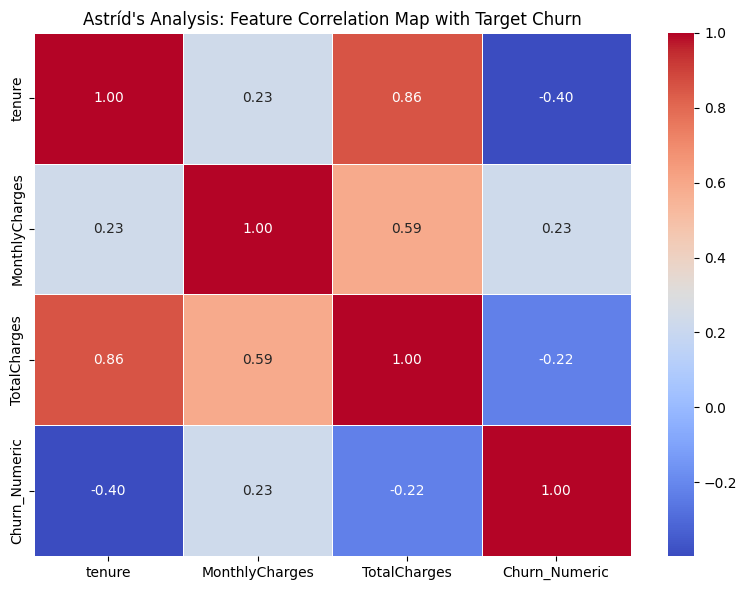

<Figure size 640x480 with 0 Axes>


[SUCCESS] Heatmap generated and saved as 'astrid_correlation_heatmap.png'.
Analysis Note: Tenure shows a strong negative correlation with churn, indicating loyal customers stay.


In [17]:
# ==========================================================
# FEATURE ENGINEERING & EXPLORATORY CORRELATION ANALYSIS
# CONTRIBUTED BY: ASTRÍD LORENZANA
# ==========================================================

# Defining function for visualization of seaborn heatmap for our data
def plot_correlation_heatmap(df, features):
    correlation_matrix = df[features].corr()

    plt.figure(figsize = (8,6))
    sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f", linewidths = 0.5)
    plt.title("Astríd's Analysis: Feature Correlation Map with Target Churn")
    plt.tight_layout()
    plt.show()

# Selected core continuous features and engineered encoded matrices
train_df_balanced['Churn_Numeric'] = train_df_balanced['Churn'].map({'Yes': 1, 'No': 0})
core_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric']

plot_correlation_heatmap(train_df_balanced, core_features)

# Exporting visual artifact to the repository
plt.savefig('astrid_correlation_heatmap.png')
plt.show()


print("\n[SUCCESS] Heatmap generated and saved as 'astrid_correlation_heatmap.png'.")
print("Analysis Note: Tenure shows a strong negative correlation with churn, indicating loyal customers stay.")